In [1]:
from explore_import import  *
import ionbot_preprocess as io
import data_preprocess as dt
import hpp_checker as hpp
import data_preprocess as dt
import pyteomics.auxiliary as aux
import ast
import tpp_preprocess as tpp

import asyncio
import pickle
import time
import os
import itertools 
import time
import re
import ast
from scipy.spatial import distance
from gql import gql, Client
from gql.transport.aiohttp import AIOHTTPTransport
import asyncio

warnings.simplefilter(action='ignore', category=FutureWarning)

In [2]:
def get_peptide_position(database_peptide, protein, OPfasta):
    count_var=0
    #print(database_peptide, protein, count_var)
    prot_seq=str(OPfasta[protein].seq)
    pos=hpp.get_pep_positions(prot_seq, database_peptide)
    if len(pos)>1: pos=[pos[0]] #take first occurance in protein
    if len(pos)==0: #if didnt find peptide in protein
        # try L->I
        database_peptide = database_peptide.replace('L','I')
        prot_seq=str(OPfasta[protein].seq)
        pos=hpp.get_pep_positions(prot_seq, database_peptide)
        if len(pos)>1: pos=[pos[0]]
        if len(pos)==0:
            count_var+=1;  pos=[np.nan]
    if count_var > 0: print(database_peptide, protein, count_var)
    return pos[0]

In [3]:
# GLOBAL VARS
PIPELINE = 'ionbot_open'
PIPELINE_LW = PIPELINE.lower()

In [4]:
#base directories

root="/project/def-marie87/vvshazia/pride_reanalysis/CompOmics/oui-discovery"
processed_dir=f"{root}/oui-discovery-vv-data/processed/20251015-oui-discovery-ionbot-results"
# get processed files
processed_paths=dt.list_files(processed_dir)
# leave only non-entrapment and open search, only search files
tmp = processed_paths.copy()
for parent, files in processed_paths.items():
    if '-closed' in parent or '-entrap' in parent:
        del tmp[parent]
        continue
    if not any( 'group-walk-output.csv' in f for f in files):
        del tmp[parent]
processed_paths = tmp

# where to save pickles
results_dir = f"{root}/oui-discovery-vv-data/pickles"

20251015-oui-discovery-ionbot-results/
    PXD005833.v0.11.4/
        openprot-x-trembl-filt-global-outerjoin.csv
        PXD005833-opensearch-x-closedsearch-filt-global.csv.gz
        Metadata_PXD005833.v0.11.4-openprot.txt
        ID-rate-df-filt-hybrid.csv
        ID-rate-df-filt-False.csv
        Metadata_PXD005833.v0.11.4-canon.txt
        Metadata_PXD005833.v0.11.4-trembl.txt
        PXD005833-opensearch-x-closedsearch-filt-global-outerjoin.csv.gz
        openprot-x-trembl-filt-global.csv
        ID-rate-df-filt-custom.csv
        ID-rate-df-filt-global.csv
        ID-rate-df-filt-groupwalk.csv
        PXD005833.v0.11.4-canon/
            PXD005833.v0.11.4-canon-combined-features.csv.gz
            combined-results-w-qvalues.csv.gz
            AM15-canon/
                ionbot.first.proteins.csv
                sample-protein-inference-input.pout
                group-walk-output-peptide-vv.csv
                ionbot.features.csv
                ionbot.first.csv
                

In [6]:
OPfasta_file="/project/def-marie87/vvshazia/pride_reanalysis/CompOmics/oui-discovery/oui-discovery-vv-data/raw/msfragger_pride_reanalysis/concatenated-fastas/20241102-openprot-database_ionbot_db/concat.fasta"
input_file = open(OPfasta_file)
OPfasta = SeqIO.to_dict(SeqIO.parse(OPfasta_file, "fasta"))

In [57]:
#https://ftp.ensembl.org/pub/release-106/fasta/homo_sapiens/dna/
ENSfasta_file="./../oui-discovery-vv-data/raw/ionbot_openprot/Homo_sapiens.GRCh38.dna.primary_assembly.fa"
input_file = open(ENSfasta_file)
ENSfasta = SeqIO.to_dict(SeqIO.parse(ENSfasta_file, "fasta"))

### Select peptides with isoSAAV

#### Load PSM

In [7]:
psm_filt = []
for parent, files in processed_paths.items():
    if ".ipynb_checkpoints" in parent: continue
    for file in files:
        if file == 'group-walk-output.csv': #-db
            spectrum_file = '-'.join(parent.split('/')[-1].split('-')[:-1])
            search_database = parent.split('/')[-1].split('-')[-1]
            dataset = parent.split('/')[-2].split('-')[0]
            data = pd.read_csv(os.path.join(parent, file))
            data['spectrum_file'] = spectrum_file
            data['search_database'] = search_database
            data['dataset'] = dataset
            # from Enrico
            # fixes issue with some files being .RAW and other being .raw
            #data.spectrum_file = data.spectrum_file.apply(lambda x: x.split('.')[0])
            # in some mgf files the 'spectrum title' includes the file name, making the spectrum title unique.
            # when the file name is NOT included, spectrum titles are NOT unique, and this can mess up some analysis.
            #data.spectrum_title = data.spectrum_file + ':' + data.spectrum_title.apply(lambda x: x.split(':')[-1])
            psm_filt += [data]
psm_filt = pd.concat(psm_filt)
# NOTE: decoys are retained
psm_filt = psm_filt[(psm_filt['q.value'] < 0.01)&(psm_filt['isCanonical'] != 'Contam')]

# str to list
psm_filt['proteins'] = psm_filt['proteins'].apply(lambda x: x.split(';'))
# indicate proteotypic peptides
psm_filt['isProteotypic'] = psm_filt['proteins'].apply(lambda x: len(x)==1)
# peptide class
psm_filt["peptide_class"]=psm_filt["proteins"].apply(tpp.classify_peptide_tpp)

/tmp/ipykernel_3868611/2595102683.py:9: DtypeWarning: Columns (11) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(os.path.join(parent, file))
/tmp/ipykernel_3868611/2595102683.py:9: DtypeWarning: Columns (11) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(os.path.join(parent, file))


#### Load peptide

In [8]:
pep_filt = []
for parent, files in processed_paths.items():
    if ".ipynb_checkpoints" in parent: continue
    for file in files:
        if file == 'group-walk-output-peptide-vv.csv' :
            spectrum_file = '-'.join(parent.split('/')[-1].split('-')[:-1])
            search_database = parent.split('/')[-1].split('-')[-1]
            dataset = parent.split('/')[-2].split('-')[0]
            data = pd.read_csv(os.path.join(parent, file))
            data['spectrum_file'] = spectrum_file
            data['search_database'] = search_database
            data['dataset'] = dataset
            pep_filt += [data]
pep_filt = pd.concat(pep_filt)
# NOTE: only target peptides are left
pep_filt = pep_filt[(pep_filt['subset_max_rank'] == True)&(pep_filt['isCanonical'] != 'Contam')]

# str to list
#pep_filt['protein'] = pep_filt['protein'].apply(lambda x: ast.literal_eval(x))
pep_filt['proteins'] = pep_filt['proteins'].apply(lambda x: x.split(';'))
# indicate proteotypic peptides
pep_filt['isProteotypic'] = pep_filt['proteins'].apply(lambda x: len(x)==1)
# peptide class
pep_filt["peptide_class"]=pep_filt["proteins"].apply(tpp.classify_peptide_tpp)

#### Merge PSM and peptide

In [9]:
# Select PSM maching peptide level
psmpep_filt_op = psm_filt[psm_filt['search_database'] == 'openprot']
print('All OP psm', len(psmpep_filt_op))
psmpep_filt_op = psmpep_filt_op[psmpep_filt_op['database_peptide'].isin(pep_filt[pep_filt['search_database'] == 'openprot']['database_peptide'].tolist())]
psmpep_filt_op.reset_index(drop=True,inplace=True)
print('Peptide-level psm', len(psmpep_filt_op))

All OP psm 323529
Peptide-level psm 313941


#### Annotate modifications

In [10]:
from Download_UnimodDB import *

In [11]:
def PTM_string_to_masses_list(ptm_string, unimod):
    if ptm_string=='Unmodified':
        return 'Unmodified'
    # if a peptide has 2 or more possible modified forms, take only 1
    x = ptm_string.split('_or_')[0]
    x = x.split('||')
    x = [_.split('|') for _ in x]
    x = {a:re.split('[][]',b) for a,b in x}
    x = [(int(a),b[3],int(b[1])) for a,b in x.items()]
    x = [(a,b,getPTMmass(c,unimod)) for a,b,c in x]    
    return x
#Modify to parce 9999 not by unimod_id but by code_name
def PTM_string_to_masses_list_9999(ptm_string, unimod, unimod_df):
    if ptm_string=='Unmodified':
        return 'Unmodified'
    # if a peptide has 2 or more possible modified forms, take only 1
    #print(ptm_string)
    x = ptm_string.split('_or_')[0]
    x = x.split('||')
    x = [_.split('|') for _ in x]
    #print(x)
    x = {a:re.split('[][]',b) for a,b in x}
    #print(x)
    x = [(int(a),b[3],int(b[1]) if "9999" not in b[1] else b[2]) for a,b in x.items()]
    x = [(a,b,getPTMmass(c,unimod) if not isinstance(c,str) 
          else float(unimod_df[unimod_df.code_name==c].mono_mass.iloc[0]) if c in unimod_df.code_name.tolist()
         else np.nan) for a,b,c in x]    
    return x

In [12]:
def Download_Unimod_Dict_names():
    unimod = Download_UnimodDB()
    condensed_unimod = {}
    for uni_id,df in unimod.groupby("unimod_id").__iter__():
        condensed_unimod[uni_id] = {}
        condensed_unimod[uni_id]['residues'] = "".join([_ for _ in df.residue if '-' not in _])
        condensed_unimod[uni_id]['mono_mass'] = [_ for _ in set(df.mono_mass)][0]
        condensed_unimod[uni_id]['code_name'] = [_ for _ in set(df.code_name)][0]
        condensed_unimod[uni_id]['full_name'] = [_ for _ in set(df.full_name)][0]
        condensed_unimod[uni_id]['classification'] = [_ for _ in set(df.classification)][0]
        
    return condensed_unimod

In [13]:
# 3-letter to 1-letter amino acid mapping
aa_map = {
    "Ala": "A", "Cys": "C", "Asp": "D", "Glu": "E", "Phe": "F",
    "Gly": "G", "His": "H", "Ile": "I", "Lys": "K", "Leu": "L",
    "Met": "M", "Asn": "N", "Pro": "P", "Gln": "Q", "Arg": "R",
    "Ser": "S", "Thr": "T", "Val": "V", "Trp": "W", "Tyr": "Y",
    "Xle": "L",  # Xle usually refers to Leu/Ile, mapped to Leu ("L") here
    "CamCys": "C", "MetOx": "M"  # Optional: include PTMs if needed
}

# Your list of mutations
mutations = ['His2Asn', 'His2Asp', 'Ala->Ser', 'Ala->Thr', 'Ala->Asp', ...]  # etc.

# Function to extract 1-letter code of the target amino acid
def extract_target_aa(mutation):
    if "->" in mutation:
        target = mutation.split("->")[1]
    elif "2" in mutation:
        target = mutation.split("2")[1]
    else:
        return None  # or raise error if unexpected format

    return aa_map.get(target, "?")  # return '?' if unknown

In [14]:
unimod = Download_Unimod_Dict_names()
unimod_df=pd.DataFrame.from_dict(unimod, orient='index')

In [15]:
#mark substitutions
unimod_df["isSubstitution"]=unimod_df.full_name.apply(lambda x: "substitution" in x)
unimod_df_subs=unimod_df[unimod_df["isSubstitution"]]
#to what residue is change
unimod_df_subs["subs_to_residue"]=unimod_df_subs.code_name.apply(lambda x: extract_target_aa(x))

/tmp/ipykernel_3868611/3502357356.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  unimod_df_subs["subs_to_residue"]=unimod_df_subs.code_name.apply(lambda x: extract_target_aa(x))


In [17]:
# Remove retention times in parentheses
psmpep_filt_op['modifications_noRT'] = psmpep_filt_op['modifications'].str.replace(r'\([^)]*\)', '', regex=True)

# Convert modifications to mass lists
psmpep_filt_op['modifications_masses'] = psmpep_filt_op['modifications'].map(
    lambda x: PTM_string_to_masses_list_9999(x, unimod, unimod_df)
)

# Extract list of masses and total mass shift in one pass
def extract_mass_info(mods):
    if mods == 'Unmodified':
        return [0], 0
    masses = [mod[2] for mod in mods]
    return masses, np.sum(masses)

mass_info = psmpep_filt_op['modifications_masses'].map(extract_mass_info)
psmpep_filt_op[['masses', 'tot_mass_shift']] = pd.DataFrame(mass_info.tolist(), index=psmpep_filt_op.index)
psmpep_filt_op['tot_mass_shift'] = psmpep_filt_op['tot_mass_shift'].fillna(0)

# Precompute lookups for substitutions and classification
mass_to_residues = unimod_df_subs.groupby('mono_mass')['residues'].apply(set).to_dict()
mass_to_class = unimod_df.groupby('mono_mass')['classification'].apply(list).to_dict()
known_sub_masses = set(mass_to_residues.keys())

def has_substitution(peptide, masses):
    for m in masses:
        if m in known_sub_masses:
            residues = mass_to_residues[m]
            if any(aa in residues for aa in peptide):
                return True
    return False

psmpep_filt_op['isSubstitution'] = [
    has_substitution(peptide, masses)
    for peptide, masses in zip(psmpep_filt_op['database_peptide'], psmpep_filt_op['masses'])
]

psmpep_filt_op['masses_classification'] = psmpep_filt_op['masses'].map(
    lambda masses: [mass_to_class.get(m, []) for m in masses]
)

#### Select isoSAAV

In [18]:
def check_substitution(mod_masses, peptide):
    # Skip "Unmodified"
    if mod_masses == "Unmodified":
        return False
    # For each mass modification
    for _, _, mass in mod_masses:
        residues = mass_to_residues.get(mass)
        if residues:
            peptide = set(peptide)
            # Any AA in peptide match the allowed residues
            if peptide & set(residues):
                return True
    return False

In [19]:
# Precompute a mapping from mono_mass to residue list
mass_to_residues = (
    unimod_df_subs.groupby("mono_mass")["residues"]
    .apply(list)
    .to_dict()
)

In [20]:
#now check that the expected residues of these mass shifts are present in the peptides (without concidering predicted PTM position)
#coution false also can meed Unmodified or non-substitution ptm

psmpep_filt_op["isSubstitution_residue"] = [
    check_substitution(mods, pep)
    for mods, pep in zip(psmpep_filt_op["modifications_masses"], psmpep_filt_op["database_peptide"])
]

In [21]:
#filter out mass shifts of potential substitutuins, where peptide does not contain the expected residue

print('All PSM',len(psmpep_filt_op))
peps_wsub_res=psmpep_filt_op[(psmpep_filt_op.isSubstitution)&(psmpep_filt_op.isSubstitution_residue)].database_peptide.unique()
psmpep_filt_op_isosaaav=psmpep_filt_op[psmpep_filt_op.database_peptide.isin(peps_wsub_res)]
print('PSM of peptides with isoSAAV',len(psmpep_filt_op_isosaaav))

All PSM 313941
PSM of peptides with isoSAAV 196423


/tmp/ipykernel_3868611/2434560447.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  a=psmpep_filt_op_isosaaav.groupby("database_peptide").apply(lambda x: Counter(x.isSubstitution_residue)[True]/len(x))


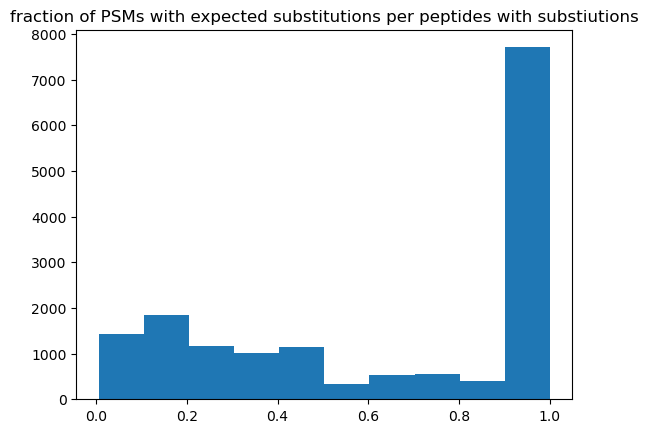

In [22]:
#how many PSMs of these peptides with potential substitutions have potential substitution

a=psmpep_filt_op_isosaaav.groupby("database_peptide").apply(lambda x: Counter(x.isSubstitution_residue)[True]/len(x))
plt.hist(a);
plt.title("fraction of PSMs with expected substitutions per peptides with substiutions");

In [23]:
#with at least one PSM with isoSAAV
(psmpep_filt_op_isosaaav.drop_duplicates("database_peptide").peptide_class.value_counts()
 /
 psmpep_filt_op.drop_duplicates("database_peptide").peptide_class.value_counts())

peptide_class
shared_btw_can_noncan    0.352447
shared_in_Canon          0.322805
unique_to_Canon          0.412838
unique_to_Noncanon       0.787879
shared_in_Noncanon       0.641509
Name: count, dtype: float64

In [24]:
# by protein - some are shared

### Creat all possible peptides with expected substitutions

In [25]:
# Precompute lookup maps
mass_to_subinfo = (
    unimod_df_subs.groupby("mono_mass")[["residues", "subs_to_residue"]]
    .apply(lambda df: list(df.itertuples(index=False)))
    .to_dict()
)
mass_values = set(mass_to_subinfo.keys())

In [26]:
records = []

for database_peptide, group in psmpep_filt_op_isosaaav.groupby("database_peptide"):
    mods = {e for l in group.modifications_masses if l != "Unmodified" for e in l}
    exp_res = [mass_to_subinfo.get(mass, []) for _, aa, mass in mods if mass in mass_values]
    exp_res = [item for sublist in exp_res for item in sublist]

    exp_res = [(r.residues, r.subs_to_residue) for r in exp_res if r.residues in database_peptide]
    mod_res = {aa for aa, _ in exp_res}
    mod_res_poss = [i for i, aa in enumerate(database_peptide) if aa in mod_res]

    exp_peptides = [
        database_peptide[:i] + aa_sub + database_peptide[i + 1:]
        for i in mod_res_poss
        for aa, aa_sub in exp_res if database_peptide[i] == aa
    ]
    saav_info = [
        (i, a, b)
        for exp_pep in exp_peptides
        for i, (a, b) in enumerate(zip(exp_pep, database_peptide))
        if a != b
    ]

    tmp = group.iloc[0][["database_peptide", "peptide_class", "proteins", 'isSubstitution']].to_dict()
    for col in ['dataset', 'spectrum_title', 'scan', 'spectrum_file',
                'observed_retention_time', 'charge', 'modifications_masses']:
        tmp[col] = group[col].tolist()

    tmp.update({
        "fraction_psm_wsub": Counter(group.isSubstitution_residue)[True] / len(group),
        "modifications_set": mods,
        "residues_to_sub": mod_res,
        "pos_to_sub": mod_res_poss,
        "sub_rule": exp_res,
        "peptides_w1sub": exp_peptides,
        "saav_info_pep": saav_info
    })

    records.append(tmp)
    
psmpep_isosaaav = pd.DataFrame(records)

In [27]:
tmp

{'database_peptide': 'YYYVCQYCPAGNWANR',
 'peptide_class': 'shared_in_Canon',
 'proteins': ['P54108-2', 'P54108-3', 'J3KPA1', 'P54108', 'B4E1S8'],
 'isSubstitution': True,
 'dataset': ['PXD005833.v0.11.4', 'PXD005833.v0.11.4'],
 'spectrum_title': ['controllerType=0 controllerNumber=1 scan=24236',
  'controllerType=0 controllerNumber=1 scan=24326'],
 'scan': [24236, 24326],
 'spectrum_file': ['AM9', 'AM12'],
 'observed_retention_time': [3756.04158, 3745.04112],
 'charge': [2, 2],
 'modifications_masses': [[(5, 'C', 57.0215), (8, 'C', 57.0215)],
  [(5, 'C', 57.0215), (8, 'C', 57.0215)]],
 'fraction_psm_wsub': 1.0,
 'modifications_set': {(5, 'C', 57.0215), (8, 'C', 57.0215)},
 'residues_to_sub': {'A', 'G'},
 'pos_to_sub': [9, 10, 13],
 'sub_rule': [('A', 'Q'), ('G', 'N'), ('A', 'Q'), ('G', 'N')],
 'peptides_w1sub': ['YYYVCQYCPQGNWANR',
  'YYYVCQYCPQGNWANR',
  'YYYVCQYCPANNWANR',
  'YYYVCQYCPANNWANR',
  'YYYVCQYCPAGNWQNR',
  'YYYVCQYCPAGNWQNR'],
 'saav_info_pep': [(9, 'Q', 'A'),
  (9, 'Q',

### Explode proteins list for individual assesment of shared peptides

In [28]:
# For shared peptides, expload the proteins list
psmpep_isosaaav['proteins_explode'] = psmpep_isosaaav['proteins']
psmpep_isosaaav = psmpep_isosaaav.explode('proteins_explode')

In [29]:
# get length and position in protein
psmpep_isosaaav["peptide_length"]=psmpep_isosaaav.database_peptide.apply(lambda x: len(x))
# indicate peptide position
psmpep_isosaaav["peptide_position"]='nan'
psmpep_isosaaav['peptide_position'] = psmpep_isosaaav.apply(lambda x: get_peptide_position(x['database_peptide'], x['proteins_explode'], OPfasta), axis=1)

### Identify the genomic coordinates of potential saavs

In [30]:
def check_OPcoords_accession_match(data):
    if data.accession.isna().all():
        #print("no accession")
        return False
    strand=data.strand.tolist()[0]
    if pd.isna(strand):
        #print("no accession matched")
        return False
    return True
    
def get_aa_triplet(protein,posav_aapos,OPcoords):
    data=OPcoords[(OPcoords.accessions==protein)|(OPcoords.accession==protein)]
    #print(data, posav_aapos)
    is_acc=check_OPcoords_accession_match(data)
    if is_acc:
        strand=data.strand.tolist()[0]
        if strand==-1:
            try:
                triplet=data.triplets.tolist()[0][posav_aapos-1-1] #-1
            except IndexError:
                print(data, posav_aapos)
                return np.nan
        else:
            try:
                triplet=data.triplets.tolist()[0][posav_aapos-1-1] #
            except IndexError:
                return np.nan
        return triplet

def get_protein_info(protein,OPcoords,givestrand=False, givechr=False, givegene=False):
    data=OPcoords[(OPcoords.accessions==protein)|(OPcoords.accession==protein)]
    is_acc=check_OPcoords_accession_match(data)
    if is_acc:
        strand=data.strand.tolist()[0]
        if givestrand:
            return strand
        if givechr:
            return data.location_chr.tolist()[0]
        if givegene:
            return data.genes.tolist()[0]

In [31]:
def get_protpos_ofaa_inpep(posinpep,peptide_position):
        #adjust indexing from 1 
        #print(peptide_position)
        posinprot=peptide_position[0]+1+posinpep
        return posinprot

In [32]:
#file was created in explore-3-noncanon-hpp.ipynb

OPcoords=pd.read_pickle("./../../../openprot_query/OPcoords.pkl")

In [33]:
# Get all relevant accessions from your working dataframe
proteins_needed = set(psmpep_isosaaav["proteins_explode"].unique())

# Filter down to only relevant proteins
OPcoords = OPcoords[
    OPcoords["accession"].isin(proteins_needed) | OPcoords["accessions"].isin(proteins_needed)
].copy()

In [34]:
#identify protein posisions of saav

psmpep_isosaaav["saav_info_prot"]=psmpep_isosaaav.apply(lambda x: 
                                [(get_protpos_ofaa_inpep(peppos,x["peptide_position"]),subto, tosub) 
                                 for peppos, subto, tosub in x["saav_info_pep"]], axis=1)

In [35]:
# --- Preindex OPcoords by accession and accessions for fast lookup ---
# Build dictionaries for O(1) access instead of filtering the DataFrame every time
opcoords_by_accession = {
    acc: row for acc, row in OPcoords.set_index("accession").iterrows()
    if pd.notna(acc)
}
opcoords_by_accessions = {
    acc: row for acc, row in OPcoords.set_index("accessions").iterrows()
    if pd.notna(acc)
}

In [40]:
# --- Fast lookup helper ---
def fast_lookup(protein):
    if protein in opcoords_by_accession:
        return opcoords_by_accession[protein]
    elif protein in opcoords_by_accessions:
        return opcoords_by_accessions[protein]
    else:
        return None

# --- Vectorized get_aa_triplet ---
def get_triplet(protein, pos, lookup):
    row = fast_lookup(protein)
    if row is None or pd.isna(row.get("strand")):
        return np.nan

    triplets = row["triplets"]
    strand = row["strand"]

    idx = pos - 2  # same as posav_aapos - 1 - 1 in your code
    if not isinstance(triplets, (list, tuple)) or idx < 0 or idx >= len(triplets):
        return np.nan

    return triplets[idx]

In [72]:
from pandarallel import pandarallel
pandarallel.initialize(progress_bar=True, nb_workers=20)

INFO: Pandarallel will run on 20 workers.
INFO: Pandarallel will use Memory file system to transfer data between the main process and workers.


In [41]:
#identify triplet of each substitution
def compute_triplets_row(row):
    protein = row["proteins_explode"]
    info = row["saav_info_prot"]
    return [(get_triplet(protein, pos, fast_lookup), subto, tosub)
            for pos, subto, tosub in info]

psmpep_isosaaav["saav_info_triplet"] = psmpep_isosaaav.parallel_apply(compute_triplets_row, axis=1)


In [48]:
# annotate chromosome, strand and gene
#note, OPcoords has genes only of uniprot sequences!

for col, field in {"strand": "strand", "chromosome": "location_chr", "gene": "genes"}.items():
    mapping = pd.concat([
        OPcoords.set_index("accession")[field],
        OPcoords.set_index("accessions")[field]
    ])
    # Make sure index is unique — keep the first occurrence
    mapping = mapping[~mapping.index.duplicated(keep="first")]
    
    psmpep_isosaaav[col] = psmpep_isosaaav["proteins_explode"].map(mapping)

In [80]:
reverse_compliment_dna={"A":"T","T":"A","C":"G","G":"C","N":"N"}
aminoacid_table={
    'A': ['GCT', 'GCC', 'GCA', 'GCG'],  # Alanine
    'R': ['CGT', 'CGC', 'CGA', 'CGG', 'AGA', 'AGG'],  # Arginine
    'N': ['AAT', 'AAC'],  # Asparagine
    'D': ['GAT', 'GAC'],  # Aspartic acid
    'C': ['TGT', 'TGC'],  # Cysteine
    'Q': ['CAA', 'CAG'],  # Glutamine
    'E': ['GAA', 'GAG'],  # Glutamic acid
    'G': ['GGT', 'GGC', 'GGA', 'GGG'],  # Glycine
    'H': ['CAT', 'CAC'],  # Histidine
    'I': ['ATT', 'ATC', 'ATA'],  # Isoleucine
    'L': ['TTA', 'TTG', 'CTT', 'CTC', 'CTA', 'CTG'],  # Leucine
    'K': ['AAA', 'AAG'],  # Lysine
    'M': ['ATG'],  # Methionine (Start codon)
    'F': ['TTT', 'TTC'],  # Phenylalanine
    'P': ['CCT', 'CCC', 'CCA', 'CCG'],  # Proline
    'S': ['TCT', 'TCC', 'TCA', 'TCG', 'AGT', 'AGC'],  # Serine
    'T': ['ACT', 'ACC', 'ACA', 'ACG'],  # Threonine
    'W': ['TGG'],  # Tryptophan
    'Y': ['TAT', 'TAC'],  # Tyrosine
    'V': ['GTT', 'GTC', 'GTA', 'GTG'],  # Valine
    '*': ['TAA', 'TAG', 'TGA']  # Stop codons
}

aminoacid_table_rev={codon:aa for aa, codons in aminoacid_table.items() for codon in codons}

def get_codon_fromfasta(poss,chromosome,ENSfasta): #strand
    #print(poss)
    if isinstance(poss,float): return np.nan
    codon=[str(ENSfasta[chromosome].seq)[pos-1] for pos in poss]
    #rev_codon=None
    #if strand==-1:
    #        rev_codon=[reverse_compliment_dna[bp] for bp in codon]
    return codon #rev_codon


In [61]:
# --- Precompute reference codons ---
def get_codons_from_positions(positions, chromosome, ENSfasta):
    """
    positions: list of 1-based positions (triplet)
    Returns list of codon nucleotides (as strings)
    """
    if positions is None or not isinstance(positions, (list, tuple)):
        return np.nan
    seq = str(ENSfasta[chromosome].seq)
    try:
        return [seq[pos-1] for pos in positions]  # 1-based to 0-based
    except IndexError:
        return np.nan

def process_saav_row(row):
    saavs = row["saav_info_triplet"]
    strand = row["strand"]
    chrom = row["chromosome"]

    if not saavs or not isinstance(saavs[0][0], list):
        return np.nan, np.nan

    refcod_row = []
    refcod_rev_row = []

    for codon_pos, subto, tosub in saavs:
        ref_codon = get_codons_from_positions(codon_pos, chrom, ENSfasta)
        refcod_row.append((ref_codon, subto, tosub))

        if strand == -1 and isinstance(ref_codon, list):
            rev_codon = [reverse_complement_dna[bp] for bp in ref_codon]
            refcod_rev_row.append((rev_codon, subto, tosub))
        else:
            refcod_rev_row.append((ref_codon, subto, tosub))

    return refcod_row, refcod_rev_row


In [63]:
#get reference codon sequence, caution strand
results = psmpep_isosaaav.parallel_apply(process_saav_row, axis=1)

# Split into two columns
psmpep_isosaaav["saav_info_refcod"] = results.apply(lambda x: x[0])
psmpep_isosaaav["saav_info_refcod_rev"] = results.apply(lambda x: x[1])

In [75]:
def check_isexpected_aa_fast(row, i, ENSfasta):
    strand = row["strand"]
    ref_aa = row["saav_info_refcod"][i][2]
    codon_list = (
        row["saav_info_refcod_rev"][i][0] if strand == -1
        else row["saav_info_refcod"][i][0]
    )

    if not isinstance(codon_list, list):
        return np.nan

    codon_str = "".join(codon_list)
    expected_codons = codon_set.get(ref_aa, set())

    if codon_str in expected_codons:
        return True

    # try correction if unexpected
    protein = row["proteins_explode"]
    triplets = triplet_lookup.get(protein)
    if not triplets:
        return False

    prot_pos = row["saav_info_prot"][i][0] - 1
    if not (0 <= prot_pos < len(triplets)):
        return False

    new_triplet = triplets[prot_pos]
    new_codon = get_codon_fromfasta(new_triplet, row["chromosome"], ENSfasta)
    if strand == -1:
        new_codon = [reverse_compliment_dna[bp] for bp in new_codon]

    new_codon_str = "".join(new_codon)
    return new_codon_str in expected_codons


In [76]:
#check if it encodes an expected aa, if not -try to correct result
#I notice that we need left shift on 1 codon with forward strand
#and to 1 right in reverse

# Pre-build lookups to avoid slow OPcoords filtering
triplet_lookup = {}
for _, row in OPcoords.iterrows():
    if isinstance(row.get("triplets"), list):
        if pd.notna(row.get("accession")):
            triplet_lookup[row["accession"]] = row["triplets"]
        if pd.notna(row.get("accessions")):
            triplet_lookup[row["accessions"]] = row["triplets"]

# Pre-cache amino acid codons
aa_to_codons = aminoacid_table
codon_set = {aa: set(codons) for aa, codons in aa_to_codons.items()}

In [81]:
pandarallel.initialize(progress_bar=True, nb_workers=50)

INFO: Pandarallel will run on 50 workers.
INFO: Pandarallel will use Memory file system to transfer data between the main process and workers.


In [82]:
def row_check_all(row):
    if not isinstance(row["saav_info_refcod"], list):
        return np.nan
    return [
        check_isexpected_aa_fast(row, i, ENSfasta)
        for i in range(len(row["saav_info_refcod"]))
    ]

psmpep_isosaaav["is_expected_aa"] = psmpep_isosaaav.parallel_apply(row_check_all, axis=1)


In [83]:
#psmpep_isosaaav.to_pickle(f'{results_dir}/{PIPELINE_LW}_psmpep_isosaaav.pkl')

In [87]:
#how many peptides have False is_expected_aa - False - 2% - this concideres same peptides but on diff positions (shared peps)

a=Counter(psmpep_isosaaav.apply(lambda x: all(x["is_expected_aa"]) if isinstance(x["saav_info_refcod"],list) else True, axis=1))
(a[False]/sum(list(a.values())))*100

2.0606652407080195

In [90]:
# proteins class with unexpected codon
a=psmpep_isosaaav[~psmpep_isosaaav["is_expected_aa"].isna()]['proteins_explode'].unique()
b=[i.startswith(("IP_","II_")) for i in a]
Counter(b)

Counter({False: 15851, True: 7911})

In [91]:
# proteins class with expected codon
a=psmpep_isosaaav['proteins_explode'].unique()
b=[i.startswith(("IP_","II_")) for i in a]
Counter(b)

Counter({False: 24940, True: 7915})

In [88]:
#how many protein accessions were NOT found in OP
len(psmpep_isosaaav[psmpep_isosaaav["is_expected_aa"].isna()]['proteins_explode'].unique())

9103

In [89]:
#how many protein accessions WERE found in OP
len(psmpep_isosaaav[~psmpep_isosaaav["is_expected_aa"].isna()]['proteins_explode'].unique())

23762

#### Check point

In [5]:
# check point
# read big df back
psmpep_isosaaav = pd.read_pickle(f'{results_dir}/{PIPELINE_LW}_psmpep_isosaaav.pkl')

In [6]:
#exclude peptides of proteins for which we dont have genomic coordinares (not found accession in OP database)

psmpep_isosaaav_filt=psmpep_isosaaav[~psmpep_isosaaav["is_expected_aa"].isna()].copy(deep=True)

In [7]:
# how many % left after filtering 

(len(psmpep_isosaaav_filt)/len(psmpep_isosaaav))*100

70.1455407793174

In [8]:
del psmpep_isosaaav

### query gnomAD

In [9]:
def get_continuous_intervals(nums):
    nums = sorted(set(nums))  # Ensure sorted and unique
    intervals = []
    
    start = prev = nums[0]
    for num in nums[1:]:
        if num == prev + 1:
            prev = num
        else:
            intervals.append((start, prev))
            start = prev = num
    intervals.append((start, prev))  # Append last interval
    return intervals
def merge_close_intervals(intervals, max_gap=1000):
    intervals.sort() # Sort intervals by start
    merged = [intervals[0]]
    for start, end in intervals[1:]:
        last_start, last_end = merged[-1]
        if start - last_end <= max_gap:
            merged[-1] = (last_start, max(end, last_end))  # Merge the intervals
        else:
            merged.append((start, end)) 
    return merged

In [10]:
#API for gnomAD

async def gnomad_response(query):
    transport = AIOHTTPTransport(url="https://gnomad.broadinstitute.org/api")
    client = Client(transport=transport, fetch_schema_from_transport=True)
    result = await client.execute_async(query)
    return result
    
async  def gnomad_api(**kwargs):
    #https://gnomad.broadinstitute.org/downloads#api    
    #request:
    # Position    # VEP annotation
    # Full allele count, and hemizygote/homozygote allele counts.    # Allele number
    # Allele frequency    # Allele counts and numbers by population    # Filters and flags for exome data
    chromosome = kwargs.get('chromosome', '1')
    genome_start = kwargs.get('genome_start', '1')
    genome_stop = kwargs.get('genome_stop', '1')
    query = gql(
        f'''
        query VariantsInGene {{
        region(chrom: "{chromosome}", start: {genome_start}, stop: {genome_stop}, reference_genome: GRCh38) {{
            variants(dataset: gnomad_r4) {{
              gene_symbol
          		gene_id
              variant_id
              pos
              rsids
              transcript_id
              consequence
              hgvsp
               exome {{     
                ac
                an
                af 
            	flags
              }}
              genome {{     
                ac
                an
                af 
            	flags
              }}
            }}
          }}
        }}
    '''
    )
    #populations {
    #              id
    #              ac
    #              an
    #              ac_hemi
    #              ac_hom
    #            }
    result= await gnomad_response(query)
    return result

def get_varvep(result,vep='missense'):
    a=result['gene']['variants']
    return [ a[i] for i in range(len(a)) if vep in a[i]['consequence'] ]
    
def get_saav(hgvsp,prot_pos,ref_aa,new_aa):
    exp_hgvsp=f"p.{hgvp_map[ref_aa]}{prot_pos}{hgvp_map[new_aa]}"
    return hgvsp==exp_hgvsp

async def check_saavs_bygene(chromosome,gencodon_sts): #gene,vep='missense'
    genome_start,genome_stop=min(gencodon_sts),max(gencodon_sts)
    #get SNPs from gnomAD
    gnomad_result= await gnomad_api(chromosome=chromosome,genome_start=genome_start,genome_stop=genome_stop) #gene_symbol=gene)
    is_saavs={}
    for gencodon_st in gencodon_sts:
        is_saav=[]
        for snp in gnomad_result["region"]['variants']:
            if gencodon_st==snp['pos']: is_saav.append(snp)
        is_saavs[gencodon_st]=is_saav
    return is_saavs

In [11]:
#creat a map of coordinates, to grep bigger ranges in one query

gnomAD_qgr={}
for chromosome, group in psmpep_isosaaav_filt.groupby("chromosome"):
    all_triplets=group['saav_info_triplet'].tolist()
    all_coordinates=list(set([e for row in all_triplets for l in row for e in l[0]]))
    chrom_intervals=get_continuous_intervals(all_coordinates)
    gnomAD_qgr[chromosome]=chrom_intervals

In [12]:
#estimate, how many queries will be made to gnomAD -> too many

len([1 for k,v in gnomAD_qgr.items() for l in v])

42085

In [13]:
#merge intervals with max gap 10000

gnomAD_qgr_m={}
for chromosome, intervals in gnomAD_qgr.items():
    new_intervals=merge_close_intervals(intervals,10000)
    gnomAD_qgr_m[chromosome]=new_intervals

In [14]:
#estimate, how many queries will be made to gnomAD -  many

len([1 for k,v in gnomAD_qgr_m.items() for l in v])

5594

In [15]:
# Skip query for now, get old dictionary
# reference query later from explor-3-massshift-saav-proteotypic

In [16]:
from datetime import datetime

In [ ]:
#query gnomAD, repeat attampts automaticly

# Load previous results if they exist
try:
    #gnomAD_qgr_res = pickle.load(open(f"{results_dir}/gnomAD_qgr_res.pickle", "rb"))
    gnomAD_qgr_m_res = pickle.load(open(f"{results_dir}/gnomAD_qgr_m_res.pickle", "rb"))
except FileNotFoundError:
    #gnomAD_qgr_res = {chrom: {} for chrom in gnomAD_qgr}
    gnomAD_qgr_m_res = {chrom: {} for chrom in gnomAD_qgr_m}

# Track progress
#progress_path = f"{results_dir}/gnomAD_qgr_progress.pickle"
progress_path = f"{results_dir}/gnomAD_qgr_m_progress.pickle"
if os.path.exists(progress_path):
    completed = pickle.load(open(progress_path, "rb"))
else:
    #completed = {chrom: set() for chrom in gnomAD_qgr}
    completed = {chrom: set() for chrom in gnomAD_qgr_m}

for chromosome, intervals in gnomAD_qgr_m.items():
    if chromosome not in gnomAD_qgr_m:
        gnomAD_qgr_res[chromosome] = {}
    if chromosome not in completed:
        completed[chromosome] = set()
        
    i = 0
    while i < len(intervals):
        if i in completed[chromosome]:
            i += 1
            continue
        interval = intervals[i]
        try:
            now = datetime.now(); formatted_time = now.strftime("%H:%M:%S")
            print(f"Processing: {chromosome}, interval {i} , {formatted_time}")
            time.sleep(8)  # Not to overwhelm the server
            result = await check_saavs_bygene(chromosome, list(range(interval[0], interval[1] + 1)))
            #gnomAD_qgr_res[chromosome].update(result)
            gnomAD_qgr_m_res[chromosome].update(result)

            # Save result and progress
            #pickle.dump(gnomAD_qgr_res, open(f"{results_dir}/gnomAD_qgr_res.pickle", "wb"))
            pickle.dump(gnomAD_qgr_m_res, open(f"{results_dir}/gnomAD_qgr_m_res.pickle", "wb"))
            completed[chromosome].add(i)
            pickle.dump(completed, open(progress_path, "wb"))

            print("Saved")
            i += 1  # Only increment if successful
        except Exception as e:
            print(f"{e} at {chromosome}, interval {i}. Retrying...")
            # Will retry same i
            continue
#start at 16:43

Processing: 1, interval 0 , 20:43:04


/home/vvshazia/miniconda3/envs/general/lib/python3.13/site-packages/gql/transport/aiohttp.py:92: UserWarning: WARNING: By default, AIOHTTPTransport does not verify ssl certificates. This will be fixed in the next major version. You can set ssl=True to force the ssl certificate verification or ssl=False to disable this warning
  warnings.warn(


Saved
Processing: 1, interval 1 , 20:43:19
Saved
Processing: 1, interval 2 , 20:43:28
Saved
Processing: 1, interval 3 , 20:43:50
Saved
Processing: 1, interval 4 , 20:43:59
Saved
Processing: 1, interval 5 , 20:44:08
Saved
Processing: 1, interval 6 , 20:44:16
Saved
Processing: 1, interval 7 , 20:44:29
Saved
Processing: 1, interval 8 , 20:44:40
Saved
Processing: 1, interval 9 , 20:44:50
Saved
Processing: 1, interval 10 , 20:45:09
Saved
Processing: 1, interval 11 , 20:45:17
Saved
Processing: 1, interval 12 , 20:45:25
Saved
Processing: 1, interval 13 , 20:45:34
Saved
Processing: 1, interval 14 , 20:45:47
Saved
Processing: 1, interval 15 , 20:45:55
Saved
Processing: 1, interval 16 , 20:46:05
Saved
Processing: 1, interval 17 , 20:46:13
Saved
Processing: 1, interval 18 , 20:46:22
Saved
Processing: 1, interval 19 , 20:46:36
Saved
Processing: 1, interval 20 , 20:46:45
Saved
Processing: 1, interval 21 , 20:46:53
Saved
Processing: 1, interval 22 , 20:47:09
Saved
Processing: 1, interval 23 , 20:47:

#### load old pickle, select variants needed

In [99]:

gnomAD_qgr_res = pickle.load(open("./../../../junk/gnomAD_qgr_res.pickle", "rb"))

In [106]:
#flatten the intervals
all_pos={chromosome:[] for chromosome in gnomAD_qgr}
for chromosome, positions in gnomAD_qgr.items():
    pos_l=[]
    for pos_st,pos_end in positions:
        pos_l.extend(list(range(pos_st,pos_end+1)))
    all_pos[chromosome]=pos_l

In [108]:
#filter previous gnomAD results with those intervals left in ranks filtering

gnomAD_qgr_res_r={chromosome:{} for chromosome in gnomAD_qgr}
for chromosome, positions in gnomAD_qgr_res.items():
    for pos, variants in positions.items():
        if pos in all_pos[chromosome]:
            gnomAD_qgr_res_r[chromosome].update({pos:variants})

In [112]:
print("expected:", np.sum([abs(interval[0]-interval[1])+1 for chrom,intervals in gnomAD_qgr.items() for interval in intervals] ))
print("got:", np.sum([len(vals) for chrom,vals in gnomAD_qgr_res_r.items() ]))

expected: 177521
got: 4146


In [113]:
#how many positions are empty

print("empty positions:", np.sum([1 for chrom,vals in gnomAD_qgr_res_r.items() for v in vals.values() if len(v)==0])/np.sum([len(vals) for chrom,vals in gnomAD_qgr_res_r.items() ]))

empty positions: 0.30028943560057886
